In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from glob import glob
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

In [3]:
BASE_DIR = "../data"  
IMG_DIR_1 = os.path.join(BASE_DIR, "HAM10000_images_part_1")
IMG_DIR_2 = os.path.join(BASE_DIR, "HAM10000_images_part_2")
METADATA_PATH = os.path.join(BASE_DIR, "HAM10000_metadata.csv")
 
# Load metadata
df = pd.read_csv(METADATA_PATH)

# Build image path mapping
all_image_paths = glob(os.path.join(IMG_DIR_1, "*.jpg")) + glob(os.path.join(IMG_DIR_2, "*.jpg"))
image_path_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in all_image_paths}
df['image_path'] = df['image_id'].map(image_path_dict)

# Drop rows with missing images (if any)
before = len(df)
df = df.dropna(subset=['image_path'])
print(f"Loaded {len(df)} images (dropped {before - len(df)} missing)")
 
# Class label info
CLASS_NAMES = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma', 'bkl': 'Benign keratosis',
    'bcc': 'Basal cell carcinoma', 'akiec': 'Actinic keratosis',
    'vasc': 'Vascular lesions', 'df': 'Dermatofibroma'
}
CLASSES = sorted(CLASS_NAMES.keys())  # Alphabetical for consistent encoding
NUM_CLASSES = len(CLASSES)
 
print(f"Classes ({NUM_CLASSES}): {CLASSES}")

Loaded 10015 images (dropped 0 missing)
Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


#### ENCODE LABELS

In [4]:
# Convert string labels to integer codes and one-hot vectors
 
# Create label encoding: alphabetical order
label_to_idx = {label: idx for idx, label in enumerate(CLASSES)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
 
df['label_idx'] = df['dx'].map(label_to_idx)
 
print("\nLabel encoding:")
for label, idx in sorted(label_to_idx.items(), key=lambda x: x[1]):
    count = len(df[df['dx'] == label])
    print(f"  {idx} -> {label:6s} ({CLASS_NAMES[label]:25s}) : {count} images")


Label encoding:
  0 -> akiec  (Actinic keratosis        ) : 327 images
  1 -> bcc    (Basal cell carcinoma     ) : 514 images
  2 -> bkl    (Benign keratosis         ) : 1099 images
  3 -> df     (Dermatofibroma           ) : 115 images
  4 -> mel    (Melanoma                 ) : 1113 images
  5 -> nv     (Melanocytic nevi         ) : 6705 images
  6 -> vasc   (Vascular lesions         ) : 142 images


#### TRAIN / VALIDATION / TEST SPLIT (by lesion_id)

In [8]:
'''
CRITICAL: Split by lesion_id, NOT image_id
Same lesion photographed multiple times must stay in the same split
Otherwise the model "memorizes" the lesion and test metrics are inflated
'''
print("\n" + "=" * 60)
print("SPLITTING DATA (by lesion_id to prevent leakage)")
print("=" * 60)
 
# Get unique lesion_ids with their diagnosis
lesion_df = df.groupby('lesion_id').first().reset_index()[['lesion_id', 'dx', 'label_idx']]
 
print(f"Unique lesions: {len(lesion_df)}")
print(f"Total images:   {len(df)}")
print(f"Avg images per lesion: {len(df)/len(lesion_df):.2f}")
 
# First split: 70% train, 30% temp (which becomes 15% val + 15% test)
train_lesions, temp_lesions = train_test_split(
    lesion_df,
    test_size=0.30,
    random_state=42,
    stratify=lesion_df['dx']  # Maintain class proportions
)
 
# Second split: 50/50 of the 30% -> 15% val, 15% test
val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.50,
    random_state=42,
    stratify=temp_lesions['dx']
)
 
# Map lesion splits back to image-level dataframe
train_ids = set(train_lesions['lesion_id'])
val_ids = set(val_lesions['lesion_id'])
test_ids = set(test_lesions['lesion_id'])

df_train = df[df['lesion_id'].isin(train_ids)].copy()
df_val = df[df['lesion_id'].isin(val_ids)].copy()
df_test = df[df['lesion_id'].isin(test_ids)].copy()
 
print(f"\nSplit results (image-level):")
print(f"  Train:      {len(df_train):5d} images ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Validation: {len(df_val):5d} images ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test:       {len(df_test):5d} images ({len(df_test)/len(df)*100:.1f}%)")
print(f"  Total:      {len(df_train)+len(df_val)+len(df_test):5d}")
 
# Verify no leakage
train_lesion_set = set(df_train['lesion_id'])
val_lesion_set = set(df_val['lesion_id'])
test_lesion_set = set(df_test['lesion_id'])
 
assert len(train_lesion_set & val_lesion_set) == 0, "LEAKAGE: train-val overlap!"
assert len(train_lesion_set & test_lesion_set) == 0, "LEAKAGE: train-test overlap!"
assert len(val_lesion_set & test_lesion_set) == 0, "LEAKAGE: val-test overlap!"


SPLITTING DATA (by lesion_id to prevent leakage)
Unique lesions: 7470
Total images:   10015
Avg images per lesion: 1.34

Split results (image-level):
  Train:       6981 images (69.7%)
  Validation:  1532 images (15.3%)
  Test:        1502 images (15.0%)
  Total:      10015


#### CLASS DISTRIBUTION PER SPLIT


CLASS DISTRIBUTION PER SPLIT
       Train  Validation  Test  Total
dx                                   
akiec    222          53    52    327
bcc      361          82    71    514
bkl      772         160   167   1099
df        71          24    20    115
mel      773         173   167   1113
nv      4683        1018  1004   6705
vasc      99          22    21    142


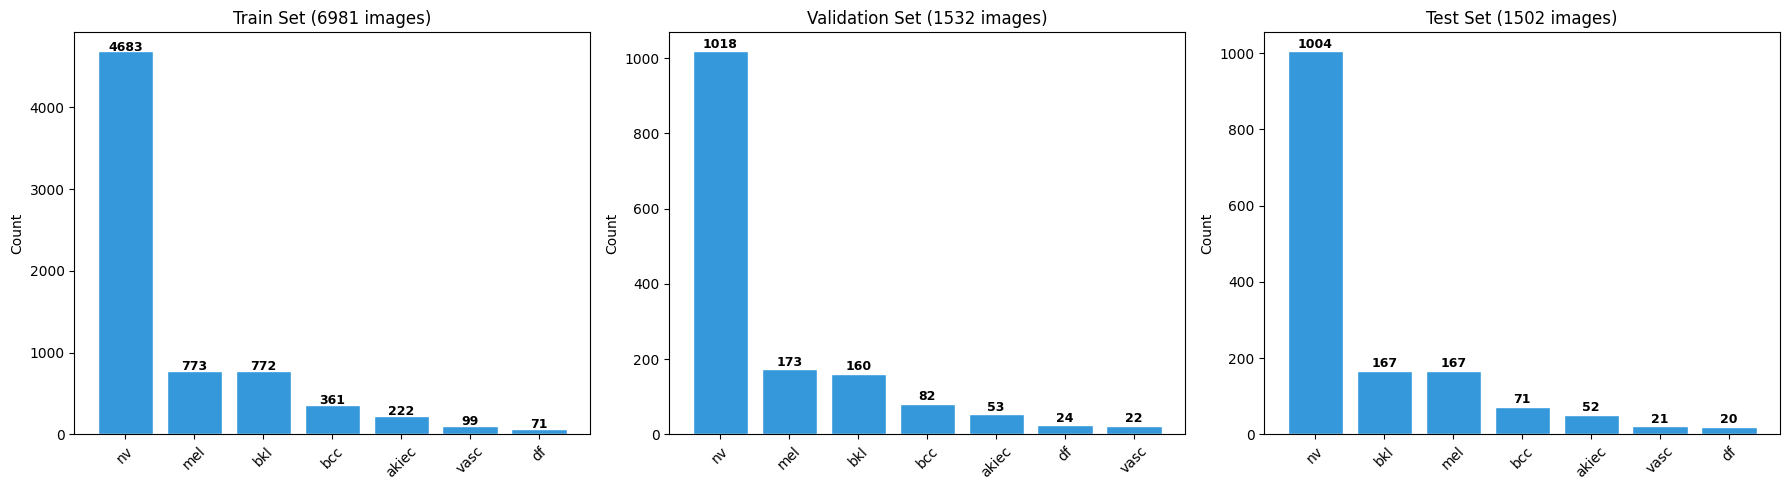

In [10]:
print("\n" + "=" * 60)
print("CLASS DISTRIBUTION PER SPLIT")
print("=" * 60)
 
split_dist = pd.DataFrame({
    'Train': df_train['dx'].value_counts(),
    'Validation': df_val['dx'].value_counts(),
    'Test': df_test['dx'].value_counts()
}).fillna(0).astype(int)
 
split_dist['Total'] = split_dist.sum(axis=1)
print(split_dist)
 
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, data) in zip(axes, [('Train', df_train), ('Validation', df_val), ('Test', df_test)]):
    counts = data['dx'].value_counts()
    ax.bar(counts.index, counts.values, color='#3498DB', edgecolor='white')
    ax.set_title(f"{name} Set ({len(data)} images)")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)
    for i, (cls, cnt) in enumerate(counts.items()):
        ax.text(i, cnt + 10, str(cnt), ha='center', fontsize=9, fontweight='bold')
 
plt.tight_layout()
# plt.savefig("outputs/stage2_split_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

#### COMPUTE CLASS WEIGHTS

In [12]:
# Handle severe class imbalance by computing weights
# Higher weight = model pays MORE attention to rare classes
print("\n" + "=" * 60)
print("CLASS WEIGHTS (for imbalance handling)")
print("=" * 60)
 
train_labels = df_train['label_idx'].values
 
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
 
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
 
print("\nComputed class weights:")
for idx in sorted(class_weight_dict.keys()):
    label = idx_to_label[idx]
    count = len(df_train[df_train['label_idx'] == idx])
    print(f"  {idx} ({label:6s}): weight = {class_weight_dict[idx]:.4f}  (train count: {count})")
 
print(f"\nInterpretation:")
print(f"  Weight > 1.0 = underrepresented class (model pays MORE attention)")
print(f"  Weight < 1.0 = overrepresented class  (model pays LESS attention)")
print(f"  Weight = 1.0 = perfectly balanced")
 


CLASS WEIGHTS (for imbalance handling)

Computed class weights:
  0 (akiec ): weight = 4.4923  (train count: 222)
  1 (bcc   ): weight = 2.7626  (train count: 361)
  2 (bkl   ): weight = 1.2918  (train count: 772)
  3 (df    ): weight = 14.0463  (train count: 71)
  4 (mel   ): weight = 1.2901  (train count: 773)
  5 (nv    ): weight = 0.2130  (train count: 4683)
  6 (vasc  ): weight = 10.0736  (train count: 99)

Interpretation:
  Weight > 1.0 = underrepresented class (model pays MORE attention)
  Weight < 1.0 = overrepresented class  (model pays LESS attention)
  Weight = 1.0 = perfectly balanced


#### IMAGE LOADING AND PREPROCESSING FUNCTION

In [13]:
IMG_SIZE = 224  # MobileNetV2 input size
 
def load_and_preprocess_image(image_path, target_size=(IMG_SIZE, IMG_SIZE)):
    """
    Load an image, resize to target_size, and normalize to [0, 1].
    Returns numpy array of shape (target_size[0], target_size[1], 3).
    """
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size, Image.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    return img_array
 
# Test on one image
test_img = load_and_preprocess_image(df_train['image_path'].iloc[0])
print(f"\nImage preprocessing test:")
print(f"  Output shape: {test_img.shape}")
print(f"  Pixel range:  [{test_img.min():.3f}, {test_img.max():.3f}]")
print(f"  Dtype:        {test_img.dtype}")
 


Image preprocessing test:
  Output shape: (224, 224, 3)
  Pixel range:  [0.180, 1.000]
  Dtype:        float32


#### LOADING ALL IMAGES INTO NUMPY ARRAYS

In [14]:
print("\n" + "=" * 60)
print("LOADING ALL IMAGES INTO MEMORY")
print("=" * 60)
 
def load_dataset(dataframe, desc=""):
    """Load all images from a dataframe into numpy arrays."""
    images = []
    labels = []
    failed = 0
 
    total = len(dataframe)
    for i, (_, row) in enumerate(dataframe.iterrows()):
        if (i + 1) % 500 == 0 or i == 0:
            print(f"  {desc}: {i+1}/{total} loaded...", end='\r')
        try:
            img = load_and_preprocess_image(row['image_path'])
            images.append(img)
            labels.append(row['label_idx'])
        except Exception as e:
            failed += 1
            continue
 
    print(f"  {desc}: {total}/{total} loaded. ({failed} failed)     ")
    return np.array(images), np.array(labels)
 
X_train, y_train = load_dataset(df_train, "Train")
X_val, y_val = load_dataset(df_val, "Validation")
X_test, y_test = load_dataset(df_test, "Test")
 
print(f"\nFinal array shapes:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  y_test:  {y_test.shape}")
 
# Memory usage
total_mb = (X_train.nbytes + X_val.nbytes + X_test.nbytes) / (1024 * 1024)
print(f"  Total memory: {total_mb:.0f} MB ({total_mb/1024:.2f} GB)")


LOADING ALL IMAGES INTO MEMORY
  Train: 6981/6981 loaded. (0 failed)     
  Validation: 1532/1532 loaded. (0 failed)     
  Test: 1502/1502 loaded. (0 failed)     

Final array shapes:
  X_train: (6981, 224, 224, 3)  y_train: (6981,)
  X_val:   (1532, 224, 224, 3)  y_val:   (1532,)
  X_test:  (1502, 224, 224, 3)  y_test:  (1502,)
  Total memory: 5751 MB (5.62 GB)


#### ONE-HOT ENCODE LABELS

In [ ]:
from tensorflow.keras.utils import to_categorical # pyright: ignore[reportMissingImports]
 
y_train_onehot = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_onehot = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_onehot = to_categorical(y_test, num_classes=NUM_CLASSES)
 
print(f"\nOne-hot encoded shapes:")
print(f"  y_train: {y_train_onehot.shape}  (example: {y_train_onehot[0]})")
print(f"  y_val:   {y_val_onehot.shape}")
print(f"  y_test:  {y_test_onehot.shape}")



One-hot encoded shapes:
  y_train: (6981, 7)  (example: [0. 0. 1. 0. 0. 0. 0.])
  y_val:   (1532, 7)
  y_test:  (1502, 7)


#### DATA AUGMENTATION

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # pyright: ignore[reportMissingImports]
 
# Training: augmentation ON
train_datagen = ImageDataGenerator(
    rotation_range=20,        # Random rotation ±20 degrees
    width_shift_range=0.1,    # Horizontal shift ±10%
    height_shift_range=0.1,   # Vertical shift ±10%
    horizontal_flip=True,     # Random horizontal flip
    vertical_flip=True,       # Random vertical flip
    zoom_range=0.1,           # Random zoom ±10%
    fill_mode='nearest'       # Fill empty pixels after transform
)
 
# Validation & Test: NO augmentation (just normalization, already done)
val_datagen = ImageDataGenerator()  # No augmentation
 
print("\nData augmentation configured:")
print("  Train: rotation(±20°), shift(±10%), flip(H+V), zoom(±10%)")
print("  Val/Test: No augmentation (raw images only)")


Data augmentation configured:
  Train: rotation(±20°), shift(±10%), flip(H+V), zoom(±10%)
  Val/Test: No augmentation (raw images only)


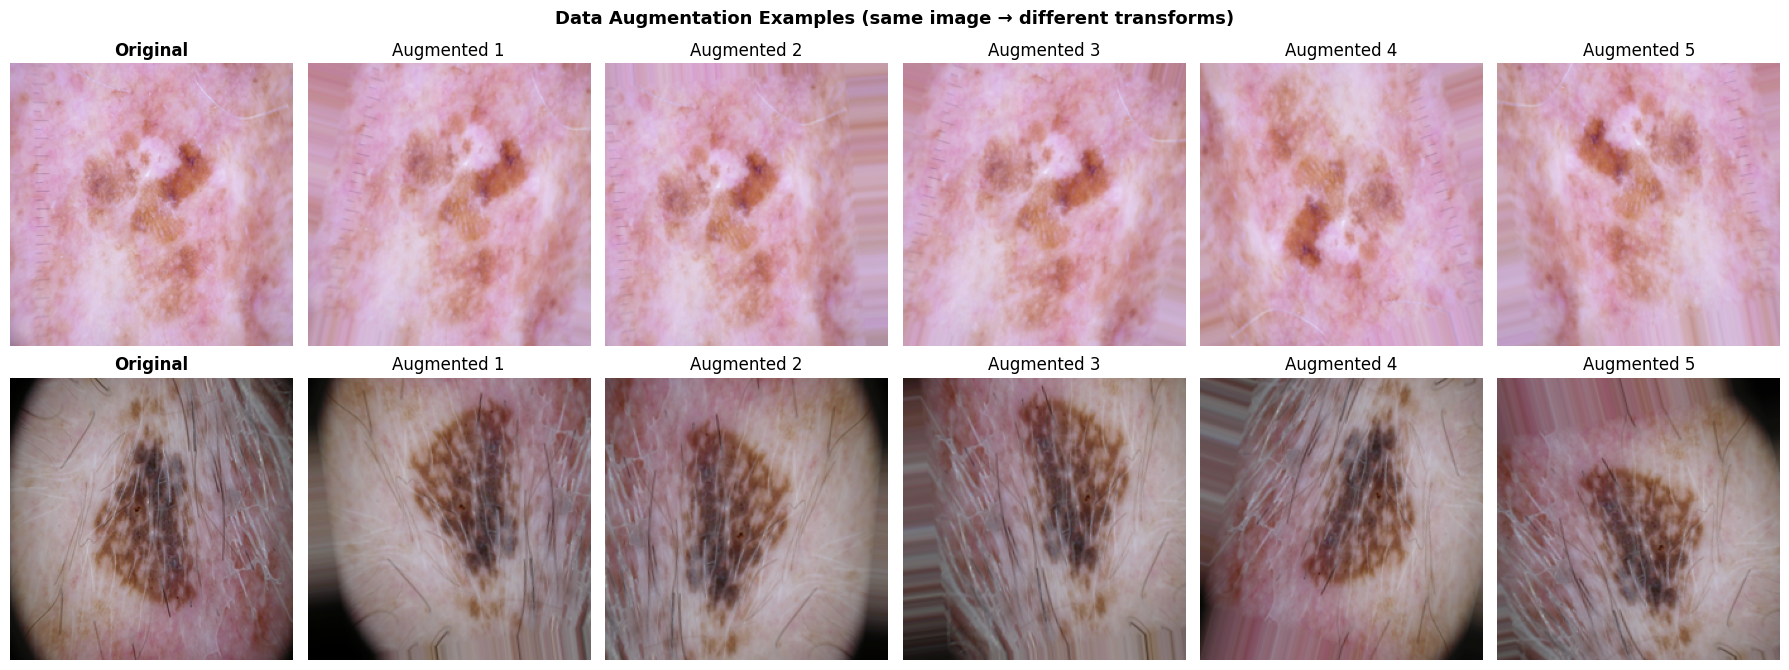

Saved: ../outputs/stage2_augmentation_examples.png

Generators created:
  Train batches per epoch: 218
  Val batches per epoch:   47
  Batch size: 32


In [18]:
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
 
# Pick a sample image
sample_img = X_train[0:1]  # Shape: (1, 224, 224, 3)
 
# Original
axes[0][0].imshow(sample_img[0])
axes[0][0].set_title("Original", fontweight='bold')
axes[0][0].axis('off')
 
axes[1][0].imshow(sample_img[0])
axes[1][0].set_title("Original", fontweight='bold')
axes[1][0].axis('off')
 
# Generate augmented versions
aug_iter = train_datagen.flow(sample_img, batch_size=1)
for i in range(1, 6):
    aug_img = next(aug_iter)[0]
    axes[0][i].imshow(np.clip(aug_img, 0, 1))
    axes[0][i].set_title(f"Augmented {i}")
    axes[0][i].axis('off')
 
# Pick a different sample
sample_img2 = X_train[100:101]
axes[1][0].imshow(sample_img2[0])
axes[1][0].set_title("Original", fontweight='bold')
axes[1][0].axis('off')
 
aug_iter2 = train_datagen.flow(sample_img2, batch_size=1)
for i in range(1, 6):
    aug_img = next(aug_iter2)[0]
    axes[1][i].imshow(np.clip(aug_img, 0, 1))
    axes[1][i].set_title(f"Augmented {i}")
    axes[1][i].axis('off')
 
plt.suptitle("Data Augmentation Examples (same image → different transforms)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../outputs/stage2_augmentation_examples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../outputs/stage2_augmentation_examples.png")
 
# ---------------------------------------------------------
# 2.12 CREATE DATA GENERATORS FOR TRAINING
# ---------------------------------------------------------
 
BATCH_SIZE = 32
 
train_generator = train_datagen.flow(
    X_train, y_train_onehot,
    batch_size=BATCH_SIZE,
    shuffle=True
)
 
val_generator = val_datagen.flow(
    X_val, y_val_onehot,
    batch_size=BATCH_SIZE,
    shuffle=False
)
 
print(f"\nGenerators created:")
print(f"  Train batches per epoch: {len(X_train) // BATCH_SIZE}")
print(f"  Val batches per epoch:   {len(X_val) // BATCH_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")

In [20]:
os.makedirs("outputs", exist_ok=True)
 
# Save as compressed numpy arrays
np.savez_compressed("outputs/stage2_preprocessed_data.npz",
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    y_train_onehot=y_train_onehot,
    y_val_onehot=y_val_onehot,
    y_test_onehot=y_test_onehot
)

In [21]:
# Save class weights and label mappings
import json
config = {
    'class_weight_dict': {str(k): v for k, v in class_weight_dict.items()},
    'label_to_idx': label_to_idx,
    'idx_to_label': {str(k): v for k, v in idx_to_label.items()},
    'class_names': CLASS_NAMES,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'num_classes': NUM_CLASSES
}
 
with open("outputs/stage2_config.json", 'w') as f:
    json.dump(config, f, indent=2)
 
file_size_mb = os.path.getsize("outputs/stage2_preprocessed_data.npz") / (1024 * 1024)
print(f"\nSaved preprocessed data: outputs/stage2_preprocessed_data.npz ({file_size_mb:.0f} MB)")
print(f"Saved config: outputs/stage2_config.json")


Saved preprocessed data: outputs/stage2_preprocessed_data.npz (1401 MB)
Saved config: outputs/stage2_config.json
